# **Information**
---

**Dato:** 19 May 2026 

**Course** Bayesian Machine Learning\
**Course number:** 02477

**Study number** s210666\
**Table number** 21

# **Part 1**
---

## **Question 1.1**

The regression model is the following model given from the task
$$
y_n = f(x_n) + \epsilon_n
$$

where the gaussian noise is
$$
\epsilon_n \sim \mathcal{N}(0,\sigma^2)
$$

and
$$
f(x)=\theta_0+\theta_1\cos\left(2\pi \frac13 x\right)+\theta_2\cos\left(2\pi \frac23 x\right)+\theta_3\cos(2\pi x)
$$

To determine the conditional distribution I use
$$
p(y_n \mid \theta, x_n = 0)
$$

I first evaluate the basis functions at $x_n=0$ for the reason that
$$
\cos(0)=1
$$

I obtain the following
$$
f(0) = \theta_0 + \theta_1 + \theta_2 + \theta_3
$$

The observation of the model is Gaussian, which is
$$
p(y_n \mid \theta,x_n) \sim \mathcal{N}(f(x_n),\sigma^2)
$$

and therefore
$$
p(y_n \mid \theta,x_n=0) \sim \mathcal{N} \left(\theta_0+\theta_1+\theta_2+\theta_3,\sigma^2\right)
$$

and since
$$
\sigma=\frac{1}{10}
$$

the variance is
$$
\sigma^2=\left(\frac{1}{10}\right)^2=0.01
$$

The final distribution is therefore
$$
p(y_n \mid \theta,x_n=0) \sim \mathcal{N} \left(\theta_0+\theta_1+\theta_2+\theta_3,0.01\right)
$$

## **Question 1.2**

I compute the MAP estimate of $\theta$ using the given dataset

The model is linear in the parameters, so I can write the following
$$
f(x)=\phi(x)^T\theta
$$

with the target vector
$$
\phi(x) = \begin{bmatrix} 1 \\
\cos\left(2\pi \frac13 x\right) \\
\cos\left(2\pi \frac23 x\right) \\
\cos(2\pi x)
\end{bmatrix}
$$

The MAP estimate for Bayesian linear regression is the following
$$
\theta_{\text{MAP}} = \left(\frac1{\sigma^2}\Phi^T\Phi+\alpha I \right)^{-1} \frac{1¸}{\sigma^2} \Phi^T y
$$

and since
$$
\sigma=0.1, \qquad \sigma^2=0.01, \qquad \frac1{\sigma^2}=100, \qquad \alpha=1
$$

I get
$$
\theta_{\text{MAP}} =\left(100\Phi^T\Phi+I\right)^{-1}(100\Phi^Ty)
$$

I make the design matrix from the dataset as
$$
x=[-0.3 \, 1.3  \, -0.7 \, 1.2 -0.2]
$$

The corresponding feature matrix is calculated through python below

In [33]:
import numpy as np

x = np.array([-0.3, 1.3, -0.7, 1.2, -0.2])
y = np.array([2.1, -1.0, 0.7, -0.7, 1.7])

Phi = np.column_stack([np.ones(len(x)), np.cos(2*np.pi*(1/3)*x), np.cos(2*np.pi*(2/3)*x), np.cos(2*np.pi*x)])
Phi

array([[ 1.        ,  0.80901699,  0.30901699, -0.30901699],
       [ 1.        , -0.91354546,  0.66913061, -0.30901699],
       [ 1.        ,  0.10452846, -0.9781476 , -0.30901699],
       [ 1.        , -0.80901699,  0.30901699,  0.30901699],
       [ 1.        ,  0.91354546,  0.66913061,  0.30901699]])

The matrix is therefore
$$
\Phi = \begin{bmatrix}
1 & 0.81 & 0.31 & -0.31\\
1 & -0.91 & 0.67 & -0.31\\
1 & 0.10 & -0.98 & -0.31\\
1 & -0.81 & 0.31 & 0.31\\
1 & 0.91 & 0.67 & 0.31
\end{bmatrix}
$$

The target vector is
$$
y = \begin{bmatrix} 2.1\\ -1.0\\ 0.7\\ -0.7\\ 1.7 \end{bmatrix}
$$

I calculate the MAP through python

In [2]:
sigma = 0.1
alpha = 1

A = (1/sigma**2) * Phi.T @ Phi + alpha * np.eye(4)
b = (1/sigma**2) * Phi.T @ y

theta_map = np.linalg.solve(A, b)
theta_map

array([ 0.51255588,  1.58660269, -0.01927582, -0.27540388])

Therefore the MAP estimate is
$$
\theta_{\text{MAP}}=[0.51 \, 1.58 \, -0.02 \, -0.28]^T
$$

## **Question 1.3**

The prior distribution is the following below
$$
\theta \sim \mathcal{N}(0,\alpha^{-1}I)
$$

since $\alpha=1$ I have
$$
\theta_1 \sim \mathcal{N}(0,1)
$$

A $95\%$ interval for a Gaussian distribution is
$$
\mu \pm 1.96\sigma
$$

For the prior
$$ 
\mu=0, \qquad \sigma=1
$$

therefore I have the following
$$
0 \pm 1.96 \cdot 1
$$

The $95\%$ prior interval is
$$
[-1.96 \, 1.96]
$$

For the posterior distribution I have
$$
p(\theta|y)=\mathcal{N}(m_N,S_N)
$$

where
$$
S_N^{-1} = \alpha I+\frac1{\sigma^2}\Phi^T\Phi
$$

and
$$
m_N = S_N\frac1{\sigma^2}\Phi^Ty
$$

The posterior covariance matrix becomes
$$
S_N = \left(I+100\Phi^T\Phi\right)^{-1}
$$

The mean and the variance is calcualted through python below



In [3]:
S_N = np.linalg.inv(np.eye(4) + 100 * Phi.T @ Phi)
m_N = S_N @ (100 * Phi.T @ y)

mean_theta1 = m_N[1]
std_theta1 = np.sqrt(S_N[1,1])

print(mean_theta1, std_theta1)


1.5866026915255775 0.05793861181440846


The mean for $\theta_1$ is
$$
m_{N,1}= 1.59
$$

The variance for $\theta_1$ is
$$
\sigma_{\theta_1} = 0.06
$$

I calculate the lower and upper bound through python below

In [4]:
lower = mean_theta1 - 1.96 * std_theta1
upper = mean_theta1 + 1.96 * std_theta1

print(lower, upper)

1.473043012369337 1.700162370681818


The $95\%$ posterior interval is
$$
1.59 \pm 1.96 \cdot 0.06
$$


and this gives the following
$$
[1.4730 \, 1.7002]
$$

## **Question 1.4**

The posterior predictive distribution is
$$
p(y^*|y,x^*) = \mathcal{N}(\mu_*,\sigma_*^2)
$$

where
$$
\mu_* = \phi(x^*)^T m_N
$$

and
$$
\sigma_*^2 = \sigma^2+\phi(x^*)^T S_N \phi(x^*)
$$

The task gives
$$
x^*=3
$$

To compute the feature vector I use
$$
\phi(3) = \begin{bmatrix}
1\\
\cos(2\pi)\\
\cos(4\pi)\\
\cos(6\pi)
\end{bmatrix}
$$

I calculate the feature vector through python below

In [34]:
x_star = 3

phi_star = np.array([1, np.cos(2*np.pi*(1/3)*x_star), np.cos(2*np.pi*(2/3)*x_star), np.cos(2*np.pi*x_star)])
phi_star

array([1., 1., 1., 1.])

The predictive mean becomes therefore
$$
\mu_* = [1 \, 1 \, 1 \, 1] \cdot m_N
$$

I now calculate the $\mu_*$ and the $\sigma_*$ through python below

In [6]:
mu_star = phi_star @ m_N
var_star = sigma**2 + phi_star @ S_N @ phi_star

print(mu_star, var_star)

1.8044788698219052 0.038719076131566034


Therefore the posterior predictive distribution is
$$
p(y^*|y,x^*=3) = \mathcal{N}(1.80,0.04)
$$

# **Part 2**
---

## **Question 2.1**

$y_n$ is the number of cups of coffee sold
$$
y_n \in {0,1,2,\dots}
$$

A suitable likelihood is therefore a Poisson distribution
$$
y_n \mid w,t_n \sim \text{Poisson}(\lambda_n)
$$

where $\lambda_n > 0$ is the expected number of cups sold.

The function from the task is
$$
f(t_n) = w_o 0 w_1 t_n
$$

Because the linear model from the task can be negative it cannot be used directly as $\lambda_n$. Therefore I use a log of the function
$$
\log(\lambda_n) = f(t_n)
$$

which means that
$$
\lambda_n = \exp(w_0 + w_1 t_n)
$$

So the model becomes therefore
$$
y_n \mid w,t_n \sim \text{Poisson}\left(\exp(w_0+w_1t_n)\right)
$$

This is appropriate because the observations are non-negative integer counts, and the exponential ensures that the predicted rate is always positive.

Since the plot shows that coffee sales decrease as temperature increases I expect therefore
$$
w_1 < 0
$$

## **Question 2.2**

The prior is
$$
w \sim \mathcal{N}(0,\alpha^{-1}I)
$$

This means that
$$
w_1 \sim \mathcal{N}(0,\alpha^{-1})
$$

and I want the following
$$
P(-3 \leq w_1 \leq 3) \approx 0.95
$$

For a Gaussian distribution the $95\%$ of the probability mass lies within
$$
\mu \pm 1.96\sigma
$$

Here
$$
\mu=0
$$

So
$$
1.96\sigma = 3
$$

Solving for $\sigma$ happens through python below
$$
\sigma = \frac{3}{1.96}
$$


In [7]:
sigma = 3 / 1.96
sigma

1.530612244897959

Sigma is therefor
$$
\sigma = 1.53
$$

The variance is also calculated through python below

In [8]:
sigma_2 = sigma**2 
sigma_2

2.3427738442315698

The variance is therefore
$$
\sigma^2 = 1.53^2 \approx 2.34
$$

Since
$$
\sigma^2=\alpha^{-1}
$$

I therefore have to calculate $\alpha = \frac{1}{\sigma^2}$

In [9]:
alpha = 1 / sigma_2
alpha

0.4268444444444445

The prior precision is therefore
$$
\alpha = 0.43
$$

# **Part 3**
---

## **Question 3.1**

The proposal distribution is symmetric and the Metropolis acceptance probability is the following below
$$
A(x^*|x_0)=\min\left(1,\frac{p(x^*)}{p(x_0)}\right)
$$

The log density is
$$
\log p(x) = -\frac{1}{2} x^Tx 0\log(1+e^{x^T1})
$$

And for
$$
x_0 = \begin{bmatrix}
-1\\
-1
\end{bmatrix},
\qquad
x^* =
\begin{bmatrix}
-2\\
-2
\end{bmatrix}
$$

I calculate this through python below

In [10]:
def log_p(x):
    x = np.asarray(x)
    ones = np.array([1, 1])
    term1 = -0.5 * (x.T @ x)
    term2 = -20 * np.log(1 + np.exp(x.T @ ones))

    return term1 + term2

x0 = np.array([-1, -1])

x_star = np.array([-2, -2])

log_p_x0 = log_p(x0)
log_p_xstar = log_p(x_star)

print("log p(x0) =", log_p_x0)
print("log p(x*) =", log_p_xstar)

log p(x0) = -3.538560220859452
log p(x*) = -4.362998558356195


This gives
$$
\log p(x_0) = -3.54
$$

and
$$
\log p(x^*) = -4.36
$$


I can now compute the acceptance probability throught python

In [11]:
ratio = np.exp(log_p_xstar - log_p_x0)
acceptance_probability = min(1, ratio)

acceptance_probability

np.float64(0.4384812017646251)

This gives
$$
A(x^*|x_0) = 0.44
$$

## **Question 3.2**

The Markov chain is
$$
x_0 =
\begin{bmatrix}
-1\\
-1
\end{bmatrix}
$$

and by running $1000$ Metropolis iterations at each iteration a new candidate point is sampled from the following
$$
q(x^*|x^{k-1}) = \mathcal{N} \left( x^{k-1}, \frac{1}{2} I \right)
$$

The candidate is accepted with probability
$$
A(x^*|x^{k-1}) = \min \left(1, \frac{p(x^*)}{p(x^{k-1})} \right)
$$

The code below follows this

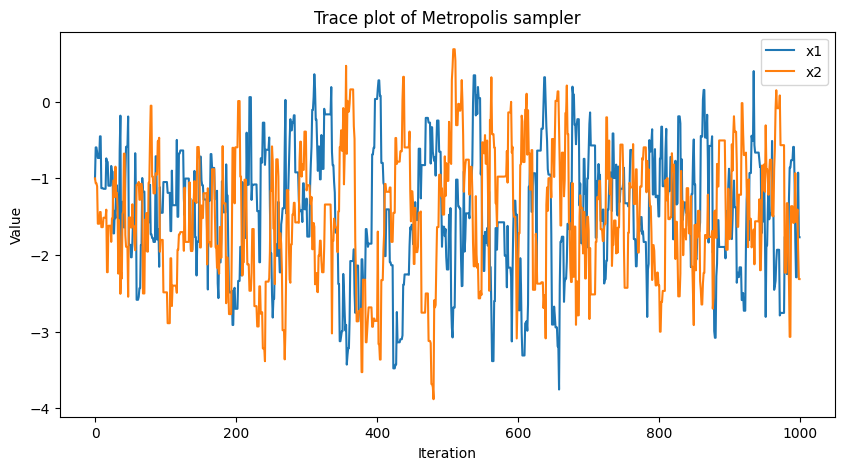

In [29]:
import matplotlib.pyplot as plt

def log_p(x):
    x = np.asarray(x)
    return -0.5 * x @ x - 20 * np.log(1 + np.exp(np.sum(x)))

def metropolis_sampler(x0, num_iter=1000):
    samples = np.zeros((num_iter, 2))
    samples[0] = x0

    current = x0.copy()
    current_log_p = log_p(current)

    proposal_cov = 0.5 * np.eye(2)

    for k in range(1, num_iter):
        proposal = np.random.multivariate_normal(current, proposal_cov)
        proposal_log_p = log_p(proposal)

        log_accept_ratio = proposal_log_p - current_log_p

        if np.log(np.random.rand()) < log_accept_ratio:
            current = proposal
            current_log_p = proposal_log_p

        samples[k] = current

    return samples

x0 = np.array([-1.0, -1.0])

samples = metropolis_sampler(x0, num_iter=1000)

plt.figure(figsize=(10, 5))
plt.plot(samples[:, 0], label="x1")
plt.plot(samples[:, 1], label="x2")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Trace plot of Metropolis sampler")
plt.legend()
plt.show()

## **Question 3.3**

The Monte Carlo estimate of
$$
\mathbb{E}[x_1x_2^2]
$$

is obtained by averaging
$$
x_1^{(s)}(x_2^{(s)})^2
$$

over all samples
$$
\mathbb{E}[x_1x_2^2] \approx \frac{1}{S} \sum_{s=1}^S x_1^{(s)}(x_2^{(s)})^2
$$

I use the samples from question 3.2 in the code below

In [ ]:
mc_estimate = np.mean(samples[:, 0] * samples[:, 1]**2)
mc_estimate

np.float64(-2.771297738866981)

So the estimate is therefore
$$
\mathbb{E}[x_1x_2^2] \approx -2.22
$$

The numerical value will vary slightly each time because the sampler is random.

## **Question 3.4**

For HMC, the leapfrog update is
$$
\nu_{1/2} = \nu_0 + \frac{\eta}{2} \nabla_x \log p(x_0)
$$

$$
x^* = x_0+\eta \nu_{1/2}
$$

$$
\nu^* = \nu_{1/2} + \frac{\eta}{2} \nabla_x \log p(x^*)
$$

From the task I have
$$
x_0 = \begin{bmatrix}
-1\\
-1
\end{bmatrix},
\qquad
\nu_0 = \begin{bmatrix}
0\\
2
\end{bmatrix},
\qquad
\eta = \frac{1}{2}
$$

The gradient is
$$
\nabla_x \log p(x) = -x-20\sigma(x^T1)1
$$

where
$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$


and I calculate this through python below

In [30]:
x0 = np.array([-1.0, -1.0])
v0 = np.array([0.0, 2.0])

eta = 0.5

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def grad_log_p(x):
    ones = np.array([1.0, 1.0])

    return -x - 20 * sigmoid(x.T @ ones) * ones

grad_x0 = grad_log_p(x0)
grad_x0

array([-1.38405844, -1.38405844])

So
$$
\nabla_x \log p(x_0) =
\begin{bmatrix}
-1.384\\
-1.384
\end{bmatrix}
$$

The half-step momentum is
$$
\nu_{1/2} =
\begin{bmatrix}
0\\
2
\end{bmatrix}
+
\frac{1}{4}
\begin{bmatrix}
-1.384\\
-1.384
\end{bmatrix}
$$



In [15]:
v_half = v0 + (eta / 2) * grad_x0
v_half

array([-0.34601461,  1.65398539])

$$
\nu_{1/2}
=
\begin{bmatrix}
-0.35\\
1.65
\end{bmatrix}
$$

Then the position update is
$$
x^* =
\begin{bmatrix}
-1\\
-1
\end{bmatrix}
+
\frac{1}{2}
\begin{bmatrix}
-0.346\\
1.654
\end{bmatrix}
$$



In [16]:
x_star = x0 + eta * v_half
x_star

array([-1.17300731, -0.17300731])

$$
x^*
=
\begin{bmatrix}
-1.17\\
-0.17
\end{bmatrix}
$$

Next I compute the gradient $x^*$ in python below

In [17]:
grad_xstar = grad_log_p(x_star)

grad_xstar

array([-2.95744666, -3.95744666])

which gives

$$
\nabla_x \log p(x^*)
=
\begin{bmatrix}
-2.95\\
-3.95
\end{bmatrix}
$$

The final momentum update is
$$
\nu^* = \nu_{1/2} + \frac{\eta}{2} \nabla_x \log p(x^*)
$$

which I calculate in python below

In [18]:
v_star = v_half + (eta / 2) * grad_xstar

v_star

array([-1.08537627,  0.66462373])

which gives

$$
\nu^*
=
\begin{bmatrix}
-1.09\\
0.67
\end{bmatrix}
$$

Thus the proposed state is therefore
$$
x^* =
\begin{bmatrix}
-1.17\\
-0.17
\end{bmatrix},
\qquad
\nu^*
=
\begin{bmatrix}
-1.09\\
0.67
\end{bmatrix}
$$

## **Question 3.5**

The HMC acceptance probability is
$$
A = \min \left(1, \exp(H(x_0,\nu_0)-H(x^*,\nu^*))\right)
$$

where
$$
H(x,\nu) = -\log p(x)+\frac12 \nu^T\nu
$$

The current state is
$$
x_0=
\begin{bmatrix}
-1\\
-1
\end{bmatrix},
\qquad
\nu_0=
\begin{bmatrix}
0\\
2
\end{bmatrix}
$$

The proposed state is
$$
x^*=
\begin{bmatrix}
-1\\
-3
\end{bmatrix},
\qquad
\nu^*=
\begin{bmatrix}
-1\\
-\frac{1}{2}
\end{bmatrix}
$$

This gets calculated through python below

In [38]:
x0 = np.array([-1.0, -1.0])
v0 = np.array([0.0, 2.0])

x_star = np.array([-1.0, -3.0])
v_star = np.array([-1.0, -0.5])

def log_p(x):
    ones = np.array([1.0, 1.0])

    return (
        -0.5 * (x.T @ x)
        - 20 * np.log(1 + np.exp(x.T @ ones))
    )

def H(x, v):

    kinetic = 0.5 * (v.T @ v)

    potential = -log_p(x)

    return potential + kinetic

H_current = H(x0, v0)
H_proposed = H(x_star, v_star)
print(H_current, H_proposed)


5.538560220859452 5.987998558356195


Evaluating the Hamiltonian gives
$$
H(x_0,\nu_0) = 5.54
$$

and
$$
H(x^*,\nu^*) = 5.99
$$

Therefore
$$
A = \min \left(1, \exp(5.54-5.99) \right)
$$

Which gets calculated in python below



In [35]:
acceptance_probability = min(1,np.exp(H_current - H_proposed))
acceptance_probability

np.float64(0.6379863840390008)

This gives the following probabiliy of accepting the proposed state
$$
A = 0.64
$$

# **Part 4**
---

## **Question 4.1**

The MAP estimate is the estimate that maximizes
$$
p(w|\mathcal{D})\propto p(\mathcal{D}|w)p(w)
$$

while the maximum likelihood estimate only maximizes
$$
p(\mathcal{D}|w)
$$

The prior is
$$
w\sim\mathcal{N}(0,I)
$$

which penalizes large parameter values. Therefore, the MAP estimate is typically closer to zero than the MLE estimate.

I compare the norms of the two estimates.

For
$$
\hat w_A=
\begin{bmatrix}
2.09\\
-0.89
\end{bmatrix}
$$

the squared norm is
$$
\begin{align*}
||\hat w_A||^2 &= 2.09^2+(-0.89)^2 \\
&= 5.1602
\end{align*}
$$

For
$$
\hat w_B=
\begin{bmatrix}
2.42\\
-1.01
\end{bmatrix}
$$

the squared norm is
$$
\begin{align*}
||\hat w_B||^2 &= 2.42^2+(-1.01)^2 \\
&= 6.8765
\end{align*}
$$

Since $\hat w_A$ has the smaller norm, it is more strongly regularized by the Gaussian prior.

Therefore
$$
\hat w_A
\text{ is the MAP estimate}
$$

and $\hat w_B$ is the maximum likelihood estimate.

## **Question 4.2**

For logistic regression, the predictive probability is
$$
p(y^*=1|y,x^*) = \sigma(w_0+w_1x^*)
$$

using the plug-in approximation.

From the task I have
$$
x^*=1
$$

and
$$
\hat w_A=
\begin{bmatrix}
2.09\\
-0.89
\end{bmatrix}
$$

First compute the linear term through python
$$
a = w_0+w_1x^*
$$



In [39]:
wA = np.array([2.09, -0.89])

x_star = 1

a = wA[0] + wA[1] * x_star
a

np.float64(1.1999999999999997)

which gives
$$
a = 1.20
$$


The sigmoid function is
$$
\sigma(a)=\frac{1}{1+e^{-a}}
$$

Thus
$$
\sigma(1.20) = \frac{1}{1+e^{-1.20}}
$$

which calculates through python

In [40]:
p = 1 / (1 + np.exp(-a))
p

np.float64(0.7685247834990175)

Therefore
$$
p(y^*=1|y,x^*=1) = 0.77
$$

## **Question 4.3**

The variational approximation is
$$
q(w)=\mathcal{N}(w|m,\tau^2 I)
$$

with
$$
m=
\begin{bmatrix}
2\\
-1
\end{bmatrix},
\qquad
\tau^2=\frac{1}{10}
$$

I estimate the predictive probability using Monte Carlo estimation.

For each sample $w^{(s)}\sim q(w)$, I compute the following in python
$$
p(y^*=1|w^{(s)},x^*) = \sigma(w_0^{(s)}+w_1^{(s)}x^*)
$$

The Monte Carlo estimator is
$$
p(y^*=1|y,x^*)
=
\frac{1}{S}
\sum_{s=1}^S
\sigma(w_0^{(s)}+w_1^{(s)}x^*)
$$

For $x^*=1$

In [23]:
m = np.array([2.0, -1.0])

tau2 = 1/10

x_star = 1

S = 10000

samples = np.random.multivariate_normal(
    mean=m,
    cov=tau2 * np.eye(2),
    size=S
)

a = samples[:, 0] + samples[:, 1] * x_star

probs = 1 / (1 + np.exp(-a))

mc_estimate = np.mean(probs)
mc_estimate

np.float64(0.7231454591207369)

This estimates
$$
p(y^*=1|y,x^*=1)
$$

using Monte Carlo sampling from the variational distribution.

The numerical value will vary slightly between runs, but should be approximately
$$
0.72
$$

## **Question 4.4**

The entropy of a multivariate Gaussian distribution
$$
\mathcal N(\mu,\Sigma)
$$

in $d$ dimensions is
$$
H[q]
=
\frac{1}{2}
\log\left(
(2\pi e)^d |\Sigma|
\right)
$$

Here
$$
q^*(w)=\mathcal N(w|m^*,\tau^2 I)
$$

with
$$
d=2,
\qquad
\tau^2=\frac{1}{10}
$$

The covariance matrix is
$$
\Sigma=\tau^2 I
$$

Therefore
$$
\begin{align*}
|\Sigma| &= (\tau^2)^2\\
&=\frac{1}{100}
\end{align*}
$$

Substituting this into the entropy formula
$$
H[q^*] = \frac{1}{2} \log \left((2\pi e)^2 \cdot \frac1{100}\right)
$$

and simplifying I get
$$
H[q^*] = \log(2\pi e)\frac12\log(100)
$$

In [24]:
np.log(100)

np.float64(4.605170185988092)

Since
$$
\log(100) = 4.61
$$

In [25]:
d = 2

tau2 = 1/10

Sigma = tau2 * np.eye(d)

entropy = 0.5 * np.log(((2 * np.pi * np.e) ** d) * np.linalg.det(Sigma))
entropy

np.float64(0.5352919734153)

Therefore the optimal variational approximation is
$$
H[q^*]
=
0.54
$$

# **Part 5**
---

## **Question 5.1**

The prior predictive distribution is
$$
y^* = f(x^*)+\epsilon^*
$$

where
$$
f(x^*) \sim \mathcal{N}(0,k(x^*,x^*))
$$

and
$$
\epsilon^* \sim \mathcal{N}(0,\sigma^2)
$$

The kernel is
$$
k(x,x')=4\exp(-||x-x'||^2)
$$

For $x^*=[0.5 \, 0.5]^T$
$$
\begin{align*}
k(x^*,x^*)& =4\exp(0) \\
&=4
\end{align*}
$$

Since
$$
\sigma^2=\frac{1}{3}
$$

I get
$$
y^*|x^* \sim \mathcal{N}\left(0,4+\frac13\right)
$$

Therefore
$$
p(y^*|x^*)=\mathcal{N}\left(0,\frac{13}{3}\right)
$$

## **Question 5.2**

The posterior predictive distribution is
$$
p(y^*|y,x^*) = \mathcal{N}(\mu_*,\sigma_*^2)
$$

where
$$
\mu_* = k_*^T(K+\sigma^2I)^{-1}y
$$

and
$$
\sigma_*^2 =
k(x^*,x^*)+\sigma^2 - k_*^T(K+\sigma^2I)^{-1}k_*
$$

Because $x^*$ is equally far from all four training points I get
$$
k_* =
\begin{bmatrix}
k(x_1,x^*)\\
k(x_2,x^*)\\
k(x_3,x^*)\\
k(x_4,x^*)
\end{bmatrix}
$$

$k_*$ is now calculated in python below

In [41]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([-0.25, 0.42, 0.49, -1.17])

x_star = np.array([0.5, 0.5])

sigma2 = 1/3

def kernel(x, x_prime):
    return 4 * np.exp(-np.sum((x - x_prime)**2))

N = len(y)

K = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        K[i, j] = kernel(X[i], X[j])

k_star = np.array([kernel(X[i], x_star) for i in range(N)])

k_star_star = kernel(x_star, x_star)
print(k_star, k_star_star)


[2.42612264 2.42612264 2.42612264 2.42612264] 4.0



Because $x^*$ is equally far from all four training points
$$
k_* =
\begin{bmatrix}
2.426\\
2.426\\
2.426\\
2.426
\end{bmatrix}
\qquad
k(x^*,x^*)=4.0
$$

I now calcualte $\mu_*$ and $\sigma_*$ through python

In [42]:

C = K + sigma2 * np.eye(N)

mu_star = k_star.T @ np.linalg.solve(C, y)

var_star = k_star_star + sigma2 - k_star.T @ np.linalg.solve(C, k_star)

print(mu_star, var_star)

-0.1582717376958272 1.3216733653799242


Which gives
$$
\mu_* = -0.16
$$

and
$$
\sigma_*^2 = 1.32
$$

Therefore
$$
p(y^*|y,x^*)= \mathcal{N}(-0.16,1.32)
$$

## **Question 5.3**

Here I are asked for
$$
p(f^*|f,x^*)
$$

where
$$
f^*=f(x^*)
$$

This is the conditional distribution of one Gaussian variable given the vector of latent function values $f$.

The joint distribution is
$$
\begin{bmatrix}
f\\
f^*
\end{bmatrix}
\sim
\mathcal{N} \left(0,
\begin{bmatrix}
K & k_*\\
k_*^T & k(x^*,x^*)
\end{bmatrix}
\right)
$$

Therefore
$$
p(f^*|f,x^*)= \mathcal{N}\left(k_*^TK^{-1}f,k(x^*,x^*)-k_*^TK^{-1}k_*\right)
$$

Using the numbers above, the conditional variance is calculated through python below

In [28]:
var_f_star = k_star_star - k_star.T @ np.linalg.solve(K, k_star)

var_f_star

np.float64(0.8542090681362904)

Which gives
$$
k(x^*,x^*)-k_*^TK^{-1}k_* = 0.85
$$

So therefore
$$
p(f^*|f,x^*) = \mathcal{N} \left(k_*^TK^{-1}f,0.85\right)
$$

## **Question 5.4**

I have the following
$$
f_2 = Af+c
$$

where
$$
f\sim\mathcal{N}(0,K)
$$

and
$$
c\sim\mathcal{N}(0,I)
$$

Since $f_2$ is a linear transformation of Gaussian variables it is also Gaussian.

The mean is therefore
$$
\mathbb{E}[f_2] = \mathbb{E}[Af+c] A\mathbb{E}[f]+\mathbb{E}[c]
$$

The covariance is
$$
\mathrm{Cov}(f_2) = \mathrm{Cov}(Af+c)
$$

Since $f$ and $c$ are independent
$$
\mathrm{Cov}(Af+c) = A\mathrm{Cov}(f)A^T+\mathrm{Cov}(c)
$$

Therefore
$$
\mathrm{Cov}(f_2) = AKA^T+I
$$

Therefore 
$$
p(f_2)=\mathcal{N}(0,AKA^T+I)
$$